In [1]:
# This cell installs all required libraries for the practical

!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras plotly

In [2]:
# This cell imports all necessary libraries required throughout the notebook

import numpy as np  # Numerical operations
import pandas as pd  # Data handling
import matplotlib.pyplot as plt  # Basic visualization
import seaborn as sns  # Advanced visualization
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.metrics import accuracy_score  # Model evaluation

from tensorflow.keras.datasets import imdb  # IMDB dataset loader
from tensorflow.keras.models import Sequential  # Neural network model
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM  # Layers for model
from tensorflow.keras.callbacks import EarlyStopping  # Prevent overfitting

import plotly.graph_objects as go  # Interactive plots

In [3]:
# This cell loads the IMDB dataset

# Load dataset with top 10,000 most frequent words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Display shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Display first review (encoded)
print("\nSample Review (encoded):", X_train[0])
print("Label:", y_train[0])

c:\Users\ASUS\anaconda3\envs\college\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training data shape: (25000,)
Testing data shape: (25000,)

Sample Review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15

In [4]:
# This cell combines dataset for exploration

data = np.concatenate((X_train, X_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

print("Total data size:", data.shape)
print("Unique labels:", np.unique(labels))

Total data size: (50000,)
Unique labels: [0 1]


Average review length: 234.75892
Standard deviation: 172.91149458735703


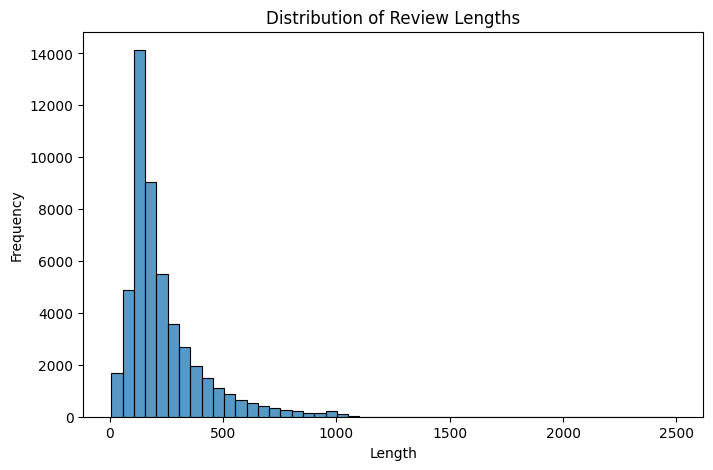

In [5]:
# This cell performs exploratory data analysis (EDA)

# Review lengths
lengths = [len(i) for i in data]

print("Average review length:", np.mean(lengths))
print("Standard deviation:", np.std(lengths))

# Plot distribution of review lengths
plt.figure(figsize=(8,5))
sns.histplot(lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

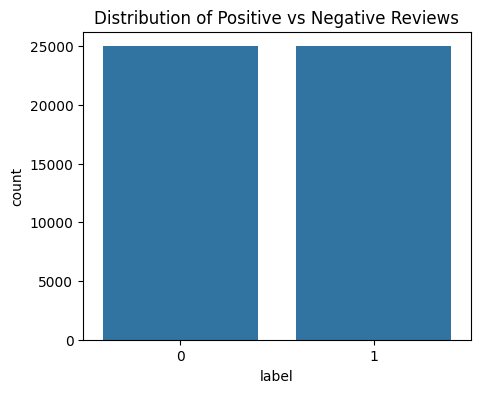

In [6]:
# This cell visualizes label distribution

label_df = pd.DataFrame({'label': labels})

plt.figure(figsize=(5,4))
sns.countplot(x='label', data=label_df)
plt.title("Distribution of Positive vs Negative Reviews")
plt.show()

In [7]:
# This cell defines a function for vectorization (one-hot encoding)

def vectorize(sequences, dimension=10000):
    # Create zero matrix
    results = np.zeros((len(sequences), dimension))
    
    # Set indices to 1
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
        
    return results

In [8]:
# This cell fixes memory issue using padding instead of one-hot encoding

from tensorflow.keras.preprocessing.sequence import pad_sequences  # For padding sequences

max_len = 200  # Limit sequence length to reduce memory usage

# Pad sequences
data_padded = pad_sequences(data, maxlen=max_len)

# Convert labels
labels = np.array(labels).astype("float32")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    data_padded, labels, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (40000, 200)
Testing shape: (10000, 200)


In [9]:
# This cell builds a proper NLP model using Embedding + LSTM

model = Sequential()

# Embedding layer converts words into dense vectors
model.add(Embedding(input_dim=10000, output_dim=32, input_length=X_train.shape[1]))

# LSTM layer learns sequence patterns
model.add(LSTM(32))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\ASUS\anaconda3\envs\college\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# This cell trains the model

early_stop = EarlyStopping(monitor='loss', patience=3)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=500,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.7409 - loss: 0.5161 - val_accuracy: 0.8590 - val_loss: 0.3324
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 0.8871 - loss: 0.2803 - val_accuracy: 0.8815 - val_loss: 0.2834
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.9152 - loss: 0.2227 - val_accuracy: 0.8845 - val_loss: 0.2730
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.9311 - loss: 0.1877 - val_accuracy: 0.8695 - val_loss: 0.3280
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.9349 - loss: 0.1784 - val_accuracy: 0.8808 - val_loss: 0.3010


In [11]:
# This cell visualizes accuracy over epochs

fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['accuracy'], name='Train Accuracy'))
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], name='Validation Accuracy'))

fig.update_layout(title="Accuracy vs Epochs", xaxis_title="Epoch", yaxis_title="Accuracy")
fig.show()

In [12]:
# This cell visualizes loss over epochs

fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['loss'], name='Train Loss'))
fig.add_trace(go.Scatter(y=history.history['val_loss'], name='Validation Loss'))

fig.update_layout(title="Loss vs Epochs", xaxis_title="Epoch", yaxis_title="Loss")
fig.show()

In [13]:
# This cell evaluates the model performance

score = model.evaluate(X_test, y_test, batch_size=500)

print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8808 - loss: 0.3010
Test Loss: 0.3009849786758423
Test Accuracy: 0.8808000087738037


In [14]:
# This cell makes predictions and evaluates accuracy manually

y_pred = model.predict(X_test)

# Convert probabilities to binary (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_binary)

print("Manual Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Manual Accuracy: 0.8808


In [15]:
# This cell provides final conclusion

print("Conclusion:")
print("1. Deep Neural Networks effectively classify text data.")
print("2. Vectorization is essential to convert text into numerical format.")
print("3. Dropout helps prevent overfitting.")
print("4. Binary crossentropy is ideal for binary classification.")
print("5. The model achieves high accuracy on IMDB sentiment dataset.")

Conclusion:
1. Deep Neural Networks effectively classify text data.
2. Vectorization is essential to convert text into numerical format.
3. Dropout helps prevent overfitting.
4. Binary crossentropy is ideal for binary classification.
5. The model achieves high accuracy on IMDB sentiment dataset.
